## Imports and Filters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from pathlib import Path
import re
from langdetect import detect, detect_langs, LangDetectException, DetectorFactory
import sys
import nltk
from nltk.corpus import stopwords

DetectorFactory.seed = 0
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\GrenAppl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
songs = pd.read_csv('dataset/songs.csv')
songs.head(3)

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.315,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
1,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.149,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
2,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.248,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [3]:
songs['year'].value_counts().sort_index(ascending=False)

year
2025        2
2024        1
2023     5566
2022    18298
2021    13759
        ...  
1925       15
1924        4
1923       26
1917        2
1900       29
Name: count, Length: 105, dtype: int64

In [4]:
filtered = songs[
    (songs['popularity'] > 0) &
    (songs['lyrics'].notna()) &
    (songs['lyrics'].str.strip() != '') &
    (songs['year'] <= 2023)
].copy().reset_index(drop=True)
print('Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)')
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
display(filtered.head(3))

Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)
Rows   : 363,056
Columns: 24


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
1,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
2,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,157.355,237973,You're not supposed to know this.\nYou're not ...,2007,Rock,23,37014,31.0,"[""6RvruFAgvsAb4B82u8wsSH""]","[""post-hardcore""]"


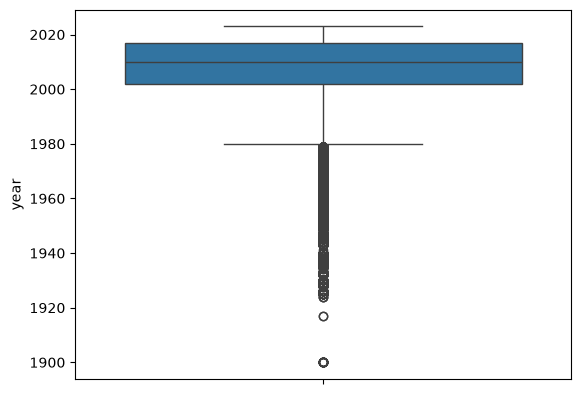

In [5]:
sns.boxplot(data=filtered, y='year')
plt.show()

In [6]:
# filtered to be 2000-2023
filtered = filtered[filtered['year'] >= 2000].reset_index(drop=True)
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
print()
print(filtered['year'].value_counts().sort_index(ascending=False))

old_filtered_len = len(filtered)

Rows   : 290,569
Columns: 24

year
2023     3729
2022    12206
2021    11149
2020    16650
2019    18323
2018    17676
2017    16278
2016    13048
2015    13692
2014    13701
2013    13232
2012    12920
2011    11456
2010    11061
2009    11231
2008    11192
2007    11789
2006    11702
2005    11257
2004    10301
2003    10293
2002     9503
2001     9230
2000     8950
Name: count, dtype: int64


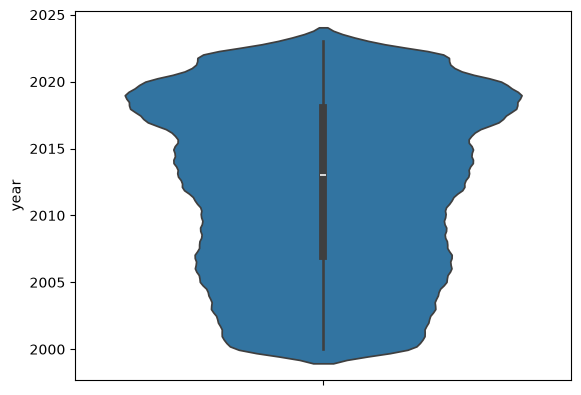

In [7]:
sns.violinplot(data=filtered, y='year')
plt.show()

---
## Lyrics Cleaning and Checks

In [8]:
# escape sequence check on lyrics

def scan_escape_sequences(filtered, column='lyrics'):
    """
    Scans a single DataFrame for literal escape sequences (e.g. \n, \t, \', \")
    appearing in a text column. Reports counts and example rows per escape type.
    """
    # common literal escape sequences to check for
    escape_patterns = {
        r'\n': r'\\n',
        r'\t': r'\\t',
        r'\r': r'\\r',
        r"\'": r"\\'",
        r'\"': r'\\"',
        r'\\': r'\\\\',
        r'\u': r'\\u[0-9a-fA-F]{4}',   # \uXXXX unicode escapes
        r'\x': r'\\x[0-9a-fA-F]{2}',   # \xXX hex escapes
    }

    print(f"Scanning column '{column}' (n={len(filtered)})")
    print('=' * 50)

    if column not in filtered.columns:
        print(f"  Column '{column}' not found.")
        return

    texts = filtered[column].dropna().astype(str)
    found_any = False

    for name, pattern in escape_patterns.items():
        matches = texts.str.contains(pattern, regex=True, na=False)
        count = matches.sum()

        if count > 0:
            found_any = True
            print(f"  '{name}' literal escape found in {count} rows ({count/len(texts)*100:.1f}%)")

            # show one example, truncated, with context around the match
            example_text = texts[matches].iloc[0]
            match_obj = re.search(pattern, example_text)
            if match_obj:
                start = max(0, match_obj.start() - 30)
                end = min(len(example_text), match_obj.end() + 30)
                snippet = example_text[start:end]
                print(f"    example: ...{snippet}...")

    if not found_any:
        print("  No literal escape sequences found.")


# example usage on a single dataframe
scan_escape_sequences(filtered)

Scanning column 'lyrics' (n=290569)
  '\n' literal escape found in 36 rows (0.0%)
    example: ..., now she running with my kids\nAnd you said I never listen\nY...
  '\'' literal escape found in 23 rows (0.0%)
    example: ...a ma na'
 Cuz once you stop it\'s gonna be crazy
 No te vayas
...
  '\"' literal escape found in 25 rows (0.0%)
    example: ...h, my God.\nWhat does he say? \"\nDear Al, big week at Fun Hom...
  '\\' literal escape found in 1 rows (0.0%)
    example: ...a)
Tm (amarte Como Te Amo)
You\\\¸re Just Another Winner (risa...
  '\u' literal escape found in 1 rows (0.0%)
    example: ...f this\nLovely, lovely night\n\u266a\nThe stars in a hazy heaven t...


In [9]:
# index col
try:
    filtered.drop(columns=['index'], inplace=True)
except:
    pass
filtered.reset_index(inplace=True)

# lyrics cleaned
filtered['lyrics'] = (
    filtered['lyrics']
    .str.lower()
    .str.replace(r'\\u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), regex=True)  # \uXXXX -> actual unicode char
    .str.replace(r'\\n', ' ', regex=True)   # literal \n -> space
    .str.replace(r'\\r', ' ', regex=True)   # literal \r -> space (just in case)
    .str.replace(r'\\t', ' ', regex=True)   # literal \t -> space
    .str.replace(r'\\"', '"', regex=True)   # literal \" -> "
    .str.replace(r"\\'", "'", regex=True)   # literal \' -> '
    .str.replace(r'\\\\', '', regex=True)   # stray literal backslashes -> remove
    .str.replace(r'\s+', ' ', regex=True)   # collapse multiple spaces/real newlines into one
    .str.strip()
)

# valid lyrics col as temp True
filtered['is_valid_lyrics'] = True

In [10]:
# index and lyrics
display(filtered['index'].value_counts())

scan_escape_sequences(filtered)
print()
print('=== BEFORE ===')
print(songs['lyrics'][0])
print()
print('=== AFTER ===')
print(filtered['lyrics'][0])

index
0         1
1         1
2         1
3         1
4         1
         ..
290564    1
290565    1
290566    1
290567    1
290568    1
Name: count, Length: 290569, dtype: int64

Scanning column 'lyrics' (n=290569)
  No literal escape sequences found.

=== BEFORE ===
Fuck the bitch, now she running with my kids\nAnd you said I never listen\nYeah, yeah\nYeah, yeah, yeah\nTell me all the things 'bout your family\nStruggle with your words, said you're rambling\nAlways play a game, bet you're gambling\nBut you got me on a string and I'm dancing\nTell me your childhood TV shows\nTell me something that I could run with\nSo I feel lucky\nSo I feel lucky, yeah\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love, oh-oh, oh-oh\nGot a tough heart 'cause your rough start\nBut you love cars and I love stars\nAnd your main dream is the only thing you see\nBut you never fuck with me, but I'm older than I seem, yeah\nComing home to you, baby\nAnd the way you flick your hair 

In [11]:
filtered['is_valid_lyrics']

0         True
1         True
2         True
3         True
4         True
          ... 
290564    True
290565    True
290566    True
290567    True
290568    True
Name: is_valid_lyrics, Length: 290569, dtype: bool

---
## Lyrics Validation Testing

In [12]:
# Get a list of the most common structural English words
common_stop_words = set(stopwords.words('english'))
print(len(common_stop_words))
print(list(common_stop_words)[:15])

# adding to stopwords
ENGLISH_COMMON_WORDS = common_stop_words.union({'like', 'hate'})
common_stop_words ^ ENGLISH_COMMON_WORDS

198
["should've", "doesn't", 'myself', 'they', 'our', 'o', "we're", 'other', 'that', 'being', 'aren', 'yourself', "mightn't", 'me', 'because']


{'hate', 'like'}

In [13]:
# Remove common LRCLIB / metadata artifacts, e.g. [Chorus], [Verse 1], timestamps
def clean_lyrics(lyrics):
    cleaned = re.sub(r'\[.*?\]', '', lyrics)
    cleaned = re.sub(r'\d{1,2}:\d{2}(\.\d+)?', '', cleaned)  # strip LRC timestamps like 00:12.34
    cleaned = cleaned.strip()
    return cleaned

# stopword fallback function in case of false non-English language
def looks_english(text, min_ratio=0.15):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    if not words:
        return False
    common_count = sum(1 for w in words if w in ENGLISH_COMMON_WORDS)
    return (common_count / len(words)) >= min_ratio

# lyrics validation function
def is_lyrics_valid(lyrics, index, min_words=20, max_non_ascii_ratio=0.15):
    """
    Checks whether a lyrics string is valid, non-empty, sufficiently long,
    and detected as English. Returns True/False.
    """
    print(f'Track index: {index:<7} |', end=' ')

    if not isinstance(lyrics, str) or not lyrics.strip():
        print('❌ INVALID -> lyrics missing or empty')
        return False

    cleaned = clean_lyrics(lyrics)

    if not cleaned:
        print('❌ INVALID -> empty after stripping metadata/timestamps')
        return False

    # Filter out instrumental / placeholder entries
    placeholder_terms = {"instrumental", "no lyrics", "lyrics not available"}
    if cleaned.lower() in placeholder_terms:
        print(f'❌ INVALID -> placeholder text ("{cleaned.lower()}")')
        return False

    # Minimum length check — avoids junk/very short entries skewing VADER scores
    word_count = len(cleaned.split())
    if word_count < min_words:
        print(f'❌ INVALID -> too short ({word_count} words, min {min_words})')
        return False

    # Reject entries with a high ratio of non-ASCII characters —
    # catches mojibake / non-Latin-script text mixed with stray English words
    non_ascii = sum(1 for c in cleaned if ord(c) > 127)
    non_ascii_ratio = non_ascii / len(cleaned)
    if non_ascii_ratio > max_non_ascii_ratio:
        print(f'❌ INVALID -> non-ASCII ratio too high ({non_ascii_ratio:.2%}, max {max_non_ascii_ratio:.0%})')
        return False

    # Language detection
    try:
        lang = detect(cleaned)
    except LangDetectException:
        print('❌ INVALID -> language detection failed')
        return False

    if lang != 'en' and not looks_english(cleaned):
        print(f'❌ INVALID -> detected language "{lang}", not English')
        return False

    print(f'✅ VALID -> {word_count} words, non-ASCII ratio {non_ascii_ratio:.2%}')
    return True

**Track lyrics flagged wrongly**

Correct with non-nlbk stopword fallback
- 3597
- 5265
- 80847
- 255840
- 287621

Still wrong before nlbk common stopwords
- 107645
- 134109
- 208721
- 280573

In [14]:
# single lyrics check
val = None
song_index = val if val != None else filtered.sample(1).index[0]
test_song = filtered.iloc[song_index]

is_lyrics_valid(
    index=song_index,
    lyrics=test_song['lyrics']
)
print('\nLYRICS:\n' + test_song['lyrics'])
print('\nDETECTED LANG %: ' + str(detect_langs(clean_lyrics(test_song['lyrics']))))

Track index: 104478  | ✅ VALID -> 194 words, non-ASCII ratio 0.00%

LYRICS:
a little girl upon the fireplace only air flying emotionless ring the bells for she could keep flying this is me, completely me end of day, we watched the sun go down i can see you're like a firework you want to save me, people will save me but this is you, completely you now it's day, but i am dreaming a man walks by, i want to be his wife i'm only here sometimes under the tree of life i'm only good sometimes to keep my time to go home like a candle wasted from burning i got shoes tired from walking calling out your name, my lips keep failing they have now forgot to sing now it's day, but i am dreaming a man walks by, i want to be his wife i'm only here sometimes under the tree of life i'm only good sometimes to keep my time to go home i'm only here sometimes under the tree of life i'm only good sometimes to keep my time to go home i'm only good sometimes under the tree of life i'm only here sometimes to keep 

In [15]:
# # test validation

# sample_size = 1000
# test_path = 'logs/valid_lyrics_test_samples.txt'
# df = filtered.sample(sample_size).reset_index()

# with open(test_path, 'w', encoding='utf-8') as log_file:
#     old_stdout = sys.stdout
#     sys.stdout = log_file
#     df['is_valid_lyrics'] = df.apply(
#         lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
#         axis=1
#     )
#     sys.stdout = old_stdout
#     display(df['is_valid_lyrics'].value_counts())

# print(f"Done. Log saved to {test_path}")
# display(df[df['is_valid_lyrics'] == False][['index', 'name', 'lyrics', 'is_valid_lyrics']].reset_index(drop=True))

In [16]:
# Timing estimate for full-dataset lyrics validation

sample_size = 1000
time_per_sample_run = (8, 16)  # observed seconds for sample size (min, max)

total_records = len(filtered)  # adjust if using a specific df/list

# rate per record, based on observed timing
min_rate = time_per_sample_run[0] / sample_size  # sec/record
max_rate = time_per_sample_run[1] / sample_size  # sec/record

est_min_seconds = total_records * min_rate
est_max_seconds = total_records * max_rate

def format_time(seconds):
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours >= 1:
        return f"{int(hours)}h {int(minutes)}m {int(sec)}s"
    elif minutes >= 1:
        return f"{int(minutes)}m {int(sec)}s"
    else:
        return f"{sec:.1f}s"

print(f"Total records: {total_records:,}")
print(f"Observed rate: {time_per_sample_run[0]}-{time_per_sample_run[1]}s per {sample_size} samples")
print(f"Estimated time for full dataset: {format_time(est_min_seconds)} - {format_time(est_max_seconds)}")

Total records: 290,569
Observed rate: 8-16s per 1000 samples
Estimated time for full dataset: 38m 44s - 1h 17m 29s


---
## Lyrics Validation Application on Dataset

In [17]:
path = 'data_filtered'
Path(path).mkdir(parents=True, exist_ok=True)
Path('logs').mkdir(parents=True, exist_ok=True)

def data_filtered_len(year):
    try:
        return len(pd.read_csv(f'{path}/songs_{year}.csv'))
    except:
        return len(filtered.loc[filtered['year'] == year])

In [25]:
for year in range(2023, 2020, -1): # 2021-2023

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

=== 2023 TRACKS ===
BEFORE: 3729 tracks
AFTER:  3577 valid tracks


is_valid_lyrics
True     3577
False     152
Name: count, dtype: int64

=== 2022 TRACKS ===
BEFORE: 12206 tracks
AFTER:  11751 valid tracks


is_valid_lyrics
True     11751
False      455
Name: count, dtype: int64

=== 2021 TRACKS ===
BEFORE: 11149 tracks
AFTER:  10805 valid tracks


is_valid_lyrics
True     10805
False      344
Name: count, dtype: int64

In [ ]:
for year in range(2020, 2017, -1): # 2018-2020
    
    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [ ]:
for year in range(2017, 2014, -1): # 2015-2017

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [ ]:
for year in range(2014, 2011, -1): # 2012-2014

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [ ]:
for year in range(2011, 2007, -1): # 2008-2011

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [ ]:
for year in range(2007, 2003, -1): # 2004-2007

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [ ]:
for year in range(2004, 1999, -1): # 2000-2004

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

In [26]:
# total tracks

def print_track_count(old_len, new_len):
    print(f'Old Track Count   : {old_len:,}')
    print(f'New Track Count   : {new_len:,}')
    print(f'Deleted Tracks    : {old_len - new_len:,}')

new_filtered_len = 0
years = filtered['year'].unique()
years = np.sort(years)[::-1]

for year in years:
    new_filtered_len += data_filtered_len(year)

print_track_count(old_filtered_len, new_filtered_len)

Old Track Count   : 290,569
New Track Count   : 289,618
Deleted Tracks    : 951
